In [12]:
from abc import ABC, abstractmethod
from typing import Dict, List, Optional, Union, Any, Tuple
from matplotlib import image
import numpy as np
import cv2
from pathlib import Path

# ============================================================================
# BASE CLASSES
# ============================================================================

class BaseFeatureExtractor(ABC):
    """Abstract base class for all feature extractors."""

    def __init__(self, name: Optional[str] = None):
        self._name = name or self.get_feature_name()

    @abstractmethod
    def extract(self, image: Union[str, np.ndarray, Path]) -> Dict[str, Any]:
        """Extract features from the input image."""
        pass

    @abstractmethod
    def get_feature_name(self) -> str:
        """Return the name of the feature."""
        pass

    @abstractmethod
    def get_feature_dim(self) -> int:
        """Return the dimensionality of the feature vector."""
        pass

    @abstractmethod
    def get_category(self) -> str:
        """Return the category (form, texture, color)."""
        pass
    def _load_image(self, image: Union[str, np.ndarray, Path]) -> np.ndarray:
        """
        Returns a grayscale image.
        - If input is path/str: loads as grayscale
        - If input is np.ndarray: safely handles 1ch, (H,W,1), 3ch, 4ch
        Output dtype: float32 (your pipeline style)
        """
        if isinstance(image, (str, Path)):
            img = cv2.imread(str(image), cv2.IMREAD_GRAYSCALE)
            if img is None:
                raise ValueError(f"Could not load image: {image}")
            return img.astype(np.float32)

        if isinstance(image, np.ndarray):
            img = image

            # (H,W,1) -> (H,W)
            if img.ndim == 3 and img.shape[2] == 1:
                img = img[:, :, 0]

            # (H,W) already gray
            if img.ndim == 2:
                return img.astype(np.float32)

            # (H,W,3) or (H,W,4) -> gray
            if img.ndim == 3 and img.shape[2] in (3, 4):
                # If RGBA, drop alpha first
                if img.shape[2] == 4:
                    img = img[:, :, :3]
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                return gray.astype(np.float32)

            raise ValueError(f"Unsupported ndarray shape for image: {img.shape}")

        raise TypeError(f"Unsupported image type: {type(image)}")


    def _load_color_image(self, image: Union[str, np.ndarray, Path]) -> np.ndarray:
        """Load image as BGR uint8."""
        if isinstance(image, (str, Path)):
            img = cv2.imread(str(image), cv2.IMREAD_COLOR)
            if img is None:
                raise ValueError(f"Could not load image: {image}")
            return img
        elif isinstance(image, np.ndarray):
            if len(image.shape) == 2:
                return cv2.cvtColor(image.astype(np.uint8), cv2.COLOR_GRAY2BGR)
            return image
        raise TypeError(f"Unsupported image type: {type(image)}")


class FormExtractor(BaseFeatureExtractor):
    """Base class for form-related extractors."""

    def __init__(self, contour_mode: str = "canny", name: Optional[str] = None):
        super().__init__(name)
        assert contour_mode in {"otsu", "canny"}
        self.contour_mode = contour_mode

    def get_category(self) -> str:
        return "form"

    def _extract_contour(self, image: Union[str, np.ndarray, Path]) -> Optional[np.ndarray]:
        # Safe grayscale load (now fixed)
        img = self._load_image(image)

        # Ensure uint8 for OpenCV
        if img.dtype != np.uint8:
            img_u8 = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        else:
            img_u8 = img

        if self.contour_mode == "otsu":
            return self._extract_contour_otsu(img_u8)
        else:
            return self._extract_contour_canny(img_u8)

    def _extract_contour_otsu(self, img_u8: np.ndarray) -> Optional[np.ndarray]:
        _, binary = cv2.threshold(img_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        if not contours:
            return None
        largest = max(contours, key=cv2.contourArea)
        contour = largest.squeeze(axis=1)
        if contour.ndim != 2 or contour.shape[0] < 4:
            return None
        return contour

    def _extract_contour_canny(self, img_u8: np.ndarray) -> Optional[np.ndarray]:
        blur = cv2.GaussianBlur(img_u8, (5, 5), 0)
        edges = cv2.Canny(blur, 50, 150)

        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)
        filled = cv2.morphologyEx(closed, cv2.MORPH_DILATE, kernel, iterations=2)

        contours, _ = cv2.findContours(filled, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        if not contours:
            return None

        largest = max(contours, key=cv2.contourArea)
        contour = largest.squeeze(axis=1)
        if contour.ndim != 2 or contour.shape[0] < 4:
            return None
        return contour




class TextureExtractor(BaseFeatureExtractor):
    """Base class for texture-related extractors."""

    def get_category(self) -> str:
        return "texture"

    def _preprocess_for_texture(self, image: Union[str, np.ndarray, Path]) -> np.ndarray:
        """Load grayscale image for texture analysis."""
        return self._load_image(image)


class ColorExtractor(BaseFeatureExtractor):
    """Base class for color-related extractors."""

    def get_category(self) -> str:
        return "color"

# ============================================================================
# FORM EXTRACTORS
# ============================================================================

class FourierDescriptorExtractor(FormExtractor):
    """Fourier descriptors for shape."""

    def __init__(
        self,
        n_coeff: int = 40,
        contour_mode: str = "canny",
        name: Optional[str] = None,
    ):
        super().__init__(contour_mode=contour_mode, name=name)
        self.n_coeff = n_coeff

    def get_feature_name(self) -> str:
        return "fourier"

    def get_feature_dim(self) -> int:
        return self.n_coeff

    def extract(self, image: Union[str, np.ndarray, Path]) -> Dict[str, Any]:
        contour = self._extract_contour(image)

        if contour is None or len(contour) < 4:
            vector = np.zeros(self.n_coeff, dtype=np.float32)
        else:
            z = contour[:, 0].astype(np.complex128) + 1j * contour[:, 1]
            z -= z.mean()
            F = np.fft.fft(z)

            denom = np.abs(F[1]) if np.abs(F[1]) > 1e-8 else 1.0
            desc = np.abs(F[1 : self.n_coeff + 1]) / denom

            vector = np.pad(
                desc,
                (0, max(0, self.n_coeff - len(desc))),
                "constant",
            ).astype(np.float32)

        norm = np.linalg.norm(vector)
        if norm > 0:
            vector /= norm

        return {
            "vector": vector,
            "metadata": {
                "n_coeff": self.n_coeff,
                "contour_mode": self.contour_mode,
            },
            "name": self._name,
        }


class OrientationHistogramExtractor(FormExtractor):
    """Rotation-invariant, length-weighted histogram of contour orientations (unsigned 0–180°)."""

    def __init__(
        self,
        bins: int = 36,
        contour_mode: str = "canny",   # we use canny by default now
        name: Optional[str] = None,
    ):
        super().__init__(contour_mode=contour_mode, name=name)
        self.bins = bins

    def get_feature_name(self) -> str:
        return "orientation"

    def get_feature_dim(self) -> int:
        return self.bins

    @staticmethod
    def _circular_align_peak(hist: np.ndarray) -> np.ndarray:
        """Rotate histogram so the dominant peak is at index 0 (rotation invariance)."""
        if hist.size == 0:
            return hist
        k = int(np.argmax(hist))
        return np.roll(hist, -k)

    def extract(self, image: Union[str, np.ndarray, Path]) -> Dict[str, Any]:
        """Extract normalized orientation histogram with:
           - unsigned angles in [0, 180)
           - segment-length weighting
           - circular peak alignment for rotation invariance
        """
        contour = self._extract_contour(image)
        if contour is None or len(contour) < 2:
            vector = np.zeros(self.bins, dtype=np.float32)
        else:
            # Differences between consecutive contour points (closed loop)
            diffs = np.diff(contour, axis=0, append=contour[:1]).astype(np.float32)
            dx = diffs[:, 0]
            dy = diffs[:, 1]

            # Segment lengths as weights
            weights = np.sqrt(dx * dx + dy * dy)

            # Angles (radians) -> degrees
            angles = np.arctan2(dy, dx)  # [-pi, pi]
            deg = (np.degrees(angles) + 360.0) % 360.0

            # Unsigned orientation: map to [0,180)
            deg = deg % 180.0

            # Weighted histogram over [0,180)
            hist, _ = np.histogram(
                deg,
                bins=self.bins,
                range=(0.0, 180.0),
                weights=weights,
                density=False,
            )

            hist = hist.astype(np.float32)

            # Rotation invariance via circular shift alignment
            hist = self._circular_align_peak(hist)

            vector = hist

        # L2 normalize for cosine similarity
        norm = np.linalg.norm(vector)
        if norm > 0:
            vector = vector / norm

        return {
            "vector": vector.astype(np.float32),
            "metadata": {
                "bins": self.bins,
                "range_deg": [0, 180],
                "unsigned": True,
                "weighted_by": "segment_length",
                "alignment": "circular_peak",
                "contour_mode": self.contour_mode,
            },
            "name": self._name,
        }


# ============================================================================
# TEXTURE EXTRACTORS  
# ============================================================================

class TamuraExtractor(TextureExtractor):
    """Tamura features: coarseness, contrast, directionality."""

    def __init__(self, kmax: int = 5, n_bins: int = 16, name: Optional[str] = None):
        super().__init__(name)
        self.kmax = kmax
        self.n_bins = n_bins

    def get_feature_name(self) -> str:
        return "tamura"

    def get_feature_dim(self) -> int:
        return 3

    def extract(self, image: Union[str, np.ndarray, Path]) -> Dict[str, Any]:
        """Extract and normalize Tamura features."""
        img = self._preprocess_for_texture(image) / 255.0
        coarseness = self._coarseness(img)
        contrast = self._contrast(img)
        directionality = self._directionality(img)
        vector = np.array([coarseness, contrast, directionality], dtype=np.float32)
        norm = np.linalg.norm(vector)
        if norm > 0:
            vector /= norm
        return {"vector": vector, "metadata": {"kmax": self.kmax, "n_bins": self.n_bins}, "name": self._name}

    def _coarseness(self, img: np.ndarray) -> float:
        h, w = img.shape
        S = np.zeros((self.kmax, h, w))
        for k in range(self.kmax):
            size = 2 ** k
            kernel = np.ones((size, size)) / (size * size)
            S[k] = cv2.filter2D(img, -1, kernel)
        E = np.zeros((self.kmax * 2, h, w))
        for k in range(self.kmax):
            size = 2 ** k
            if size < w:
                E[k] = np.abs(S[k] - np.roll(S[k], size, axis=1))
            if size < h:
                E[k + self.kmax] = np.abs(S[k] - np.roll(S[k], size, axis=0))
        best_k = np.argmax(E.reshape(self.kmax * 2, -1), axis=0) % self.kmax
        return np.mean(2 ** best_k.reshape(h, w))

    def _contrast(self, img: np.ndarray) -> float:
        mu4 = np.mean((img - img.mean()) ** 4)
        sigma2 = np.var(img)
        alpha4 = mu4 / (sigma2 ** 2 + 1e-8)
        return sigma2 ** 0.5 / (alpha4 ** 0.25 + 1e-8)

    def _directionality(self, img: np.ndarray) -> float:
        gx = cv2.Sobel(img, cv2.CV_32F, 1, 0)
        gy = cv2.Sobel(img, cv2.CV_32F, 0, 1)
        mag = np.sqrt(gx**2 + gy**2)
        theta = np.arctan2(np.abs(gy), np.abs(gx)) % np.pi
        thresh = mag.mean()
        hist, _ = np.histogram(theta[mag > thresh], bins=self.n_bins, range=(0, np.pi))
        hist = hist / (hist.sum() + 1e-8)
        return np.sum((hist - hist.mean()) ** 2)


class GaborExtractor(TextureExtractor):
    """Gabor filter bank features (mean + std per filter)."""

    def __init__(self, n_scales: int = 4, n_orientations: int = 6, name: Optional[str] = None):
        super().__init__(name)
        self.n_scales = n_scales
        self.n_orientations = n_orientations

    def get_feature_name(self) -> str:
        return "gabor"

    def get_feature_dim(self) -> int:
        return self.n_scales * self.n_orientations * 2

    def extract(self, image: Union[str, np.ndarray, Path]) -> Dict[str, Any]:
        """Extract normalized Gabor responses."""
        img = self._preprocess_for_texture(image) / 255.0
        features = []
        for s in range(self.n_scales):
            lambda_ = 4 * (2 ** s)
            for o in range(self.n_orientations):
                theta = o * np.pi / self.n_orientations
                kernel = cv2.getGaborKernel((21, 21), 5, theta, lambda_, 0.5, 0, ktype=cv2.CV_32F)
                resp = cv2.filter2D(img, cv2.CV_32F, kernel)
                features.extend([resp.mean(), resp.std()])
        vector = np.array(features, dtype=np.float32)
        norm = np.linalg.norm(vector)
        if norm > 0:
            vector /= norm
        return {
            "vector": vector,
            "metadata": {"n_scales": self.n_scales, "n_orientations": self.n_orientations},
            "name": self._name,
        }


# ============================================================================
# COLOR EXTRACTORS
# ============================================================================

class HSVHistogramExtractor(ColorExtractor):
    """3D HSV histogram."""

    def __init__(self, h_bins: int = 4, sv_bins: int = 4, name: Optional[str] = None):
        super().__init__(name)
        self.h_bins = h_bins
        self.sv_bins = sv_bins

    def get_feature_name(self) -> str:
        return "hsv_histogram"

    def get_feature_dim(self) -> int:
        return self.h_bins * self.sv_bins * self.sv_bins

    def extract(self, image: Union[str, np.ndarray, Path]) -> Dict[str, Any]:
        """Extract normalized HSV histogram."""
        img = self._load_color_image(image)
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        hist = cv2.calcHist(
            [hsv], [0, 1, 2], None, [self.h_bins, self.sv_bins, self.sv_bins], [0, 180, 0, 256, 0, 256]
        )
        hist = cv2.normalize(hist, hist).flatten()
        vector = hist.astype(np.float32)
        norm = np.linalg.norm(vector)
        if norm > 0:
            vector /= norm
        return {"vector": vector, "metadata": {"h_bins": self.h_bins, "sv_bins": self.sv_bins}, "name": self._name}


class DominantColorsExtractor(ColorExtractor):
    """Dominant colors via k-means (Lab space)."""

    def __init__(self, n_colors: int = 5, name: Optional[str] = None):
        super().__init__(name)
        self.n_colors = n_colors

    def get_feature_name(self) -> str:
        return "dominant_colors"

    def get_feature_dim(self) -> int:
        return self.n_colors * 3

    def extract(self, image: Union[str, np.ndarray, Path]) -> Dict[str, Any]:
        """Extract normalized dominant colors (sorted by prevalence) in Lab space."""
        img_bgr = self._load_color_image(image)

        # 🔹 Convert BGR → Lab
        img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)

        pixels = img_lab.reshape(-1, 3).astype(np.float32)

        criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.1)
        _, labels, centers = cv2.kmeans(
            pixels, self.n_colors, None, criteria, 10, cv2.KMEANS_PP_CENTERS
        )  # type: ignore

        counts = np.bincount(labels.flatten(), minlength=self.n_colors)
        order = np.argsort(-counts)
        centers = centers[order]

        # 🔹 Normalize OpenCV Lab encoding
        # L: [0,255] → [0,1]
        # a,b: [0,255] (128 = 0) → approx [-1,1]
        L = centers[:, 0] / 255.0
        a = (centers[:, 1] - 128.0) / 127.0
        b = (centers[:, 2] - 128.0) / 127.0
        centers_norm = np.stack([L, a, b], axis=1)

        vector = centers_norm.flatten().astype(np.float32)

        norm = np.linalg.norm(vector)
        if norm > 0:
            vector /= norm

        return {
            "vector": vector,
            "metadata": {"n_colors": self.n_colors},
            "name": self._name,
        }

# ============================================================================
# SERVICES
# ============================================================================

class FeatureExtractionService:
    """Service to extract and combine features from multiple extractors."""

    DEFAULT_WEIGHTS = {
        "form": {"fourier": 0.6, "orientation": 0.4},
        "texture": {"tamura": 0.5, "gabor": 0.5},
        "color": {"hsv_histogram": 0.2, "dominant_colors": 0.8},
    }

    def __init__(
        self, extractors: List[BaseFeatureExtractor], weights: Optional[Dict[str, Dict[str, float]]] = None
    ):
        self.extractors = extractors
        self.weights = weights or self.DEFAULT_WEIGHTS
        self._group_by_category()

    def _group_by_category(self):
        self.by_cat = {"form": [], "texture": [], "color": []}
        for e in self.extractors:
            self.by_cat[e.get_category()].append(e)

    def extract(self, image: Union[str, np.ndarray, Path], categories: Optional[List[str]] = None) -> Dict[str, Any]:
        """Extract features per category and combine weighted vectors."""
        if categories is None:
            categories = ["form", "texture", "color"]
        result = {}
        for cat in categories:
            feats = {}
            weighted_vectors = []
            for ext in self.by_cat.get(cat, []):
                feat = ext.extract(image)
                name = ext.get_feature_name()
                feats[name] = feat
                weight = self.weights.get(cat, {}).get(name, 1.0 / len(self.by_cat.get(cat, [])))
                weighted_vectors.append(feat["vector"] * weight)
            if feats and weighted_vectors:
                combined = np.concatenate(weighted_vectors)
                norm = np.linalg.norm(combined)
                if norm > 0:
                    combined /= norm
                feats["combined"] = combined
                result[cat] = feats
        return result


class SimilarityComputer:
    """Compute similarity between feature sets."""

    DEFAULT_WEIGHTS = {"form": 0.5, "texture": 0.3, "color": 0.2}

    def __init__(self, weights: Optional[Dict] = None):
        self.weights = weights or self.DEFAULT_WEIGHTS

    def compute(self, f1: Dict, f2: Dict, categories: Optional[List[str]] = None, metric: str = "euclidean") -> float:
        """
        Compute similarity between two feature sets.

        Parameters
        ----------
        f1 : dict
            Feature set 1.
        f2 : dict
            Feature set 2.
        categories : list, optional
            Categories to consider for similarity computation.
        metric : str, optional
            Metric to use for similarity computation. Must be 'cosine' or 'euclidean'.

        Returns
        -------
        float
            Similarity score between 0 and 1.
        """

        if categories is None:
            categories = list(set(f1.keys()) & set(f2.keys()))
        if not categories:
            return 0.0
        if metric not in ["cosine", "euclidean"]:
            raise ValueError("Metric must be 'cosine' or 'euclidean'.")

        sims = []
        for cat in categories:
            cat1, cat2 = f1.get(cat, {}), f2.get(cat, {})
            if "combined" not in cat1 or "combined" not in cat2:
                continue
            v1, v2 = cat1["combined"], cat2["combined"]
            if metric == "cosine":
                sim = np.dot(v1, v2)
            else:  # euclidean
                dist = np.linalg.norm(v1 - v2)
                sim = 1.0 / (1.0 + dist)
            sims.append(sim)

        if not sims:
            return 0.0

        total, total_w = 0.0, 0.0
        for cat, sim in zip(categories, sims):
            w = self.weights.get(cat, 1.0 / len(sims))
            total += w * sim
            total_w += w
        return total / total_w

    def compute_with_class_filter(self,
        query_features: Dict,query_class: str,
        base_features: Dict[str, Dict],
        categories: Optional[List[str]] = None, 
        metric: str = "euclidean",
        same_class_only: bool = False,
    ) -> List[Tuple[str, float]]:

        if categories is None:
            categories = ["form", "texture", "color"]
        
        similarities = []
        for path, data in base_features.items():
            if data.get("num_objects", 0) == 0:
                continue
            objects = data.get("objects", [])
            if isinstance(objects, np.ndarray):
                objects = objects.tolist()

            max_sim = 0.0
            for obj in objects:
                obj_class = obj.get("class_name", "unknown")
                if same_class_only and obj_class != query_class:
                    continue
                try:
                    sim = self.compute(query_features, obj["features"], metric=metric)
                    # use the object with highest similarity score
                    if sim > max_sim:
                        max_sim = sim
                except Exception:
                    continue
            if max_sim > 0:
                similarities.append((path, max_sim))
        return sorted(similarities, key=lambda x: x[1], reverse=True)



### **Color Descriptors**
#### **descripteurs de couleurs on a trouve que les histogrammes hsv donnent des resultats plus mieux que couleurs dominants. on prend les parametres suivants hsv(H_BINS = 8, SV_BINS = 8 )**

In [ ]:
import random
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt

print("Notebook working dir:", Path.cwd())

# --------------------------------------------------
# CONFIG
# --------------------------------------------------
ROOT = Path("../../")  # project root
IMAGE_DIR = ROOT / "imagenet_yolo15/images/train"
N_COLORS = 4           # 
TOP_K = 10
SAMPLE_SIZE = 200      # ✅ only compare against 100 random images
random.seed(10)      # uncomment for reproducible sampling

# --------------------------------------------------
# INIT EXTRACTOR
# --------------------------------------------------
extractor = DominantColorsExtractor(n_colors=N_COLORS)

# --------------------------------------------------
# LOAD IMAGES + SAMPLE
# --------------------------------------------------
all_paths = list(IMAGE_DIR.rglob("*.*"))
all_paths = [p for p in all_paths if p.suffix.lower() in [".jpg", ".jpeg", ".png"]]

if len(all_paths) < 2:
    raise RuntimeError(f"Only {len(all_paths)} images found in {IMAGE_DIR.resolve()}")

# keep sample size valid
sample_n = min(SAMPLE_SIZE, len(all_paths))
image_paths = random.sample(all_paths, sample_n)

# --------------------------------------------------
# PICK RANDOM QUERY IMAGE (from the sample)
# --------------------------------------------------
query_path = random.choice(image_paths)
query_feat = extractor.extract(query_path)["vector"]

# --------------------------------------------------
# COMPUTE SIMILARITIES (COSINE)
# --------------------------------------------------
results = []
for p in image_paths:
    if p == query_path:
        continue
    try:
        feat = extractor.extract(p)["vector"]
        sim = float(np.dot(query_feat, feat))  # cosine (already L2 normalized)
        results.append((p, sim))
    except Exception:
        continue

# --------------------------------------------------
# TOP-K
# --------------------------------------------------
topk = sorted(results, key=lambda x: x[1], reverse=True)[:TOP_K]

# --------------------------------------------------
# DISPLAY
# --------------------------------------------------
def show(img_path, title=None):
    img = cv2.imread(str(img_path))
    if img is None:
        plt.text(0.5, 0.5, "Could not load", ha="center", va="center")
        plt.axis("off")
        return
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis("off")
    if title:
        plt.title(title, fontsize=9)

plt.figure(figsize=(2.2 * (TOP_K + 1), 4))

plt.subplot(1, TOP_K + 1, 1)
show(query_path, "QUERY")

for i, (p, sim) in enumerate(topk, start=2):
    plt.subplot(1, TOP_K + 1, i)
    show(p, f"{sim:.2f}")

plt.tight_layout()
plt.show()

print("Query:", query_path)
print("Top results:")
for p, sim in topk:
    print(f"{sim:.4f}  {p}")

In [ ]:
import random
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt

print("Notebook working dir:", Path.cwd())

# --------------------------------------------------
# CONFIG (CHANGE THESE)
# --------------------------------------------------
ROOT = Path("../../")
IMAGE_DIR = ROOT / "imagenet_yolo15/images/train"

H_BINS = 8        # 🔴 try: 4, 6, 8
SV_BINS = 8       # 🔴 try: 2, 4, 8
TOP_K = 5
SAMPLE_SIZE = 2000
random.seed(20)
# random.seed(42)  # uncomment for reproducibility

# --------------------------------------------------
# INIT EXTRACTOR
# --------------------------------------------------
extractor = HSVHistogramExtractor(h_bins=H_BINS, sv_bins=SV_BINS)

# --------------------------------------------------
# LOAD IMAGES + SAMPLE
# --------------------------------------------------
all_paths = list(IMAGE_DIR.rglob("*.*"))
all_paths = [p for p in all_paths if p.suffix.lower() in [".jpg", ".jpeg", ".png"]]

if len(all_paths) < 2:
    raise RuntimeError(f"Only {len(all_paths)} images found in {IMAGE_DIR.resolve()}")

image_paths = random.sample(all_paths, min(SAMPLE_SIZE, len(all_paths)))

# --------------------------------------------------
# PICK RANDOM QUERY IMAGE
# --------------------------------------------------
query_path = random.choice(image_paths)
query_feat = extractor.extract(query_path)["vector"]

# --------------------------------------------------
# COMPUTE SIMILARITIES (COSINE)
# --------------------------------------------------
results = []
for p in image_paths:
    if p == query_path:
        continue
    try:
        feat = extractor.extract(p)["vector"]
        sim = float(np.dot(query_feat, feat))  # cosine similarity
        results.append((p, sim))
    except Exception:
        continue

# --------------------------------------------------
# TOP-K
# --------------------------------------------------
topk = sorted(results, key=lambda x: x[1], reverse=True)[:TOP_K]

# --------------------------------------------------
# DISPLAY
# --------------------------------------------------
def show(img_path, title=None):
    img = cv2.imread(str(img_path))
    if img is None:
        plt.text(0.5, 0.5, "Load error", ha="center", va="center")
        plt.axis("off")
        return
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis("off")
    if title:
        plt.title(title, fontsize=9)

plt.figure(figsize=(2.2 * (TOP_K + 1), 4))

plt.subplot(1, TOP_K + 1, 1)
show(query_path, f"QUERY\nH={H_BINS}, SV={SV_BINS}")

for i, (p, sim) in enumerate(topk, start=2):
    plt.subplot(1, TOP_K + 1, i)
    show(p, f"{sim:.2f}")

plt.tight_layout()
plt.show()

print(f"HSV bins → H={H_BINS}, SV={SV_BINS}")
print("Query:", query_path)
print("Top results:")
for p, sim in topk:
    print(f"{sim:.4f}  {p}")

### **Shapes Descriptors**
#### **after many tests we realised that using OTSU to extract countours is not really practical as opposed to CANNY which outperformed it since it uses gradients. so we will be using canny ofc and when it comes to number of coefficients 10 to 15 is enough since in canny we use guassien filter to remove noisey and high frequency .**

In [3]:
# app/services/yolo_service.py
from ultralytics import YOLO
import numpy as np

class YoloService:
    def __init__(self, weights_path: str, conf: float = 0.25, iou: float = 0.45, imgsz: int = 640):
        self.model = YOLO(weights_path)
        self.conf = conf
        self.iou = iou
        self.imgsz = imgsz

        # ✅ names can be dict or list depending on training
        names = getattr(self.model, "names", {})
        if isinstance(names, dict):
            self.class_names = {int(k): str(v) for k, v in names.items()}
        else:
            self.class_names = {i: str(n) for i, n in enumerate(names)}

    def detect(self, img_bgr):
        results = self.model.predict(img_bgr, conf=self.conf, iou=self.iou, imgsz=self.imgsz, verbose=False)
        r = results[0]
        out = []
        if r.boxes is None:
            return out

        for i, b in enumerate(r.boxes):
            xyxy = b.xyxy[0].cpu().numpy().astype(int).tolist()
            cls_id = int(b.cls[0].item())
            conf = float(b.conf[0].item())
            out.append({
                "id": i,
                "bbox_xyxy": xyxy,
                "class_id": cls_id,
                "class_name": self.class_names.get(cls_id, str(cls_id)),
                "confidence": conf,
            })
        return out


Image: ..\..\imagenet_yolo15\images\train\n02942699_12949.JPEG
Selected class: camera conf: 0.8934001922607422 bbox: [9, 102, 354, 329]


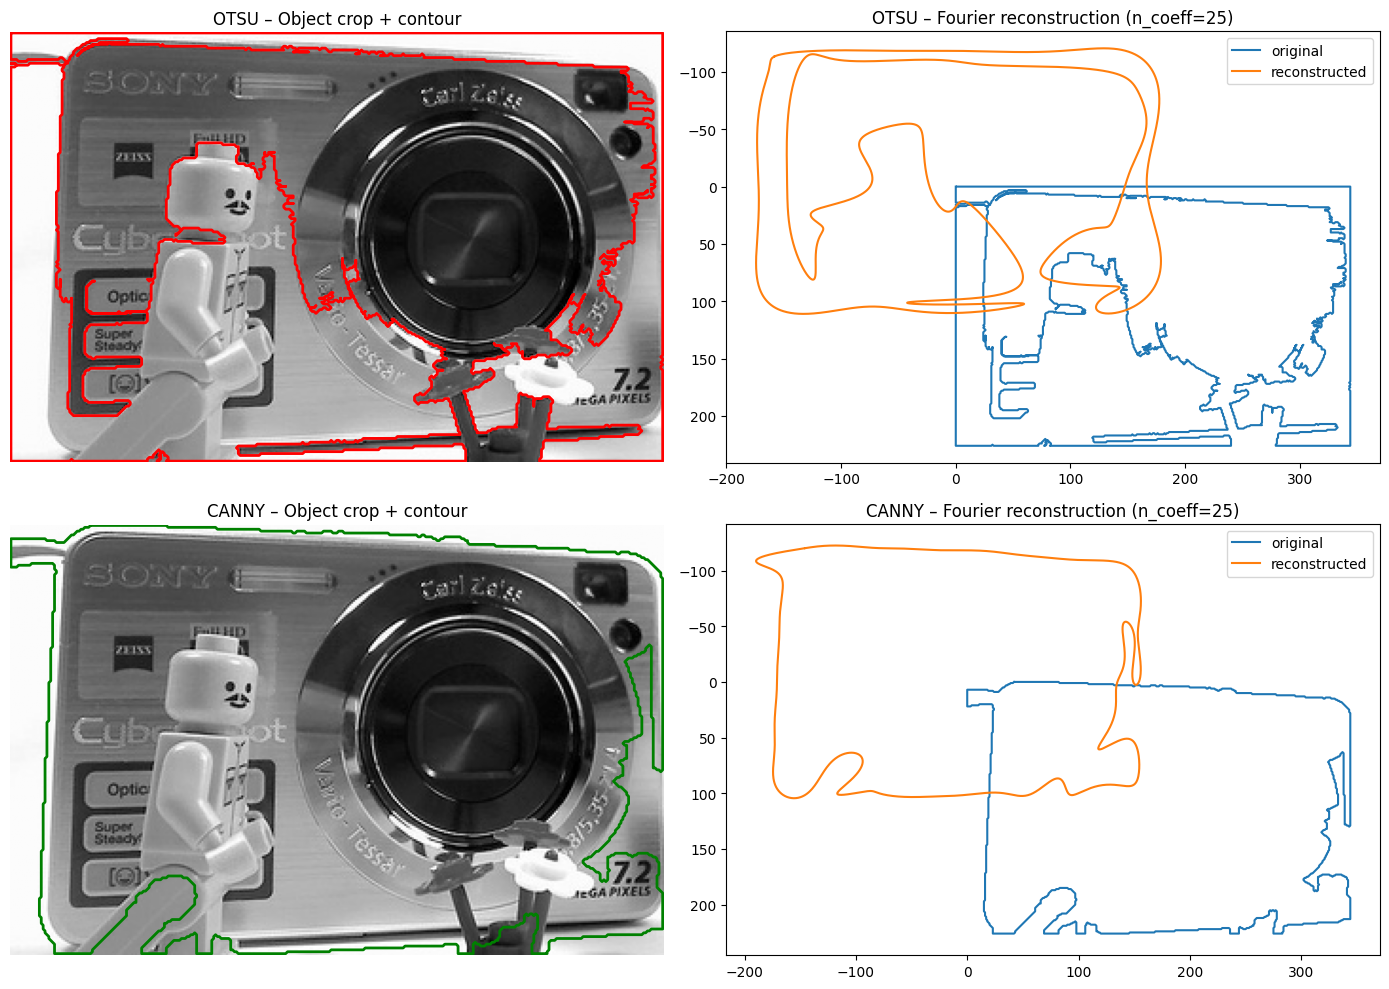

In [10]:
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------
# CONFIG
# ------------------------------------
ROOT = Path("../../")
IMG_DIR = ROOT / "imagenet_yolo15/images/train"
N_COEFF = 25
random.seed(51)

# ------------------------------------
# Init YOLO service
# ------------------------------------
yolo = YoloService(
    weights_path=Path("../../api/models/yolo/best.pt"),
    conf=0.25,
    iou=0.45,
    imgsz=640,
)

# ------------------------------------
# Pick random image
# ------------------------------------
imgs = [p for p in IMG_DIR.rglob("*") if p.suffix.lower() in {".jpg", ".png", ".jpeg", ".bmp", ".jpeg"}]
assert imgs, "No images found"
img_path = random.choice(imgs)
print("Image:", img_path)

# ------------------------------------
# Run YOLO detection
# ------------------------------------
detections = yolo.detect(str(img_path))  # str is safest for ultralytics
assert detections, "No objects detected by YOLO"

def area_xyxy(xyxy):
    x1, y1, x2, y2 = xyxy
    return max(0, x2 - x1) * max(0, y2 - y1)

det = max(detections, key=lambda d: area_xyxy(d["bbox_xyxy"]))
x1, y1, x2, y2 = map(int, det["bbox_xyxy"])
print("Selected class:", det["class_name"], "conf:", det["confidence"], "bbox:", det["bbox_xyxy"])

# ------------------------------------
# Load grayscale image (via your extractor)
# ------------------------------------
tmp = FourierDescriptorExtractor(n_coeff=N_COEFF, contour_mode="otsu")
img_gray = tmp._load_image(img_path)  # float32 grayscale

h, w = img_gray.shape[:2]
x1 = max(0, min(x1, w - 1))
x2 = max(0, min(x2, w))
y1 = max(0, min(y1, h - 1))
y2 = max(0, min(y2, h))
assert x2 > x1 and y2 > y1, "Invalid bbox after clamping"

crop = img_gray[y1:y2, x1:x2]
assert crop.size > 0, "Empty crop"

# ------------------------------------
# Instantiate BOTH extractors
# ------------------------------------
fourier_otsu  = FourierDescriptorExtractor(n_coeff=N_COEFF, contour_mode="otsu")
fourier_canny = FourierDescriptorExtractor(n_coeff=N_COEFF, contour_mode="canny")

contour_otsu  = fourier_otsu._extract_contour(crop)
contour_canny = fourier_canny._extract_contour(crop)

assert contour_otsu is not None and len(contour_otsu) > 4, "OTSU contour failed"
assert contour_canny is not None and len(contour_canny) > 4, "CANNY contour failed"

# ------------------------------------
# Fourier reconstruction helper
# ------------------------------------
def reconstruct(contour, n_coeff):
    z = contour[:, 0] + 1j * contour[:, 1]
    z -= z.mean()
    F = np.fft.fft(z)
    G = np.zeros_like(F)
    k = min(n_coeff, len(F)//2 - 1)
    if k >= 1:
        G[1:k+1] = F[1:k+1]
        G[-k:] = F[-k:]
    z_rec = np.fft.ifft(G)
    return np.column_stack([z_rec.real, z_rec.imag])

recon_otsu  = reconstruct(contour_otsu,  N_COEFF)
recon_canny = reconstruct(contour_canny, N_COEFF)

# ------------------------------------
# Visualization
# ------------------------------------
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.title("OTSU – Object crop + contour")
plt.imshow(crop, cmap="gray")
plt.plot(contour_otsu[:, 0], contour_otsu[:, 1], "r", linewidth=2)
plt.axis("off")

plt.subplot(2, 2, 2)
plt.title(f"OTSU – Fourier reconstruction (n_coeff={N_COEFF})")
plt.plot(contour_otsu[:, 0], contour_otsu[:, 1], label="original")
plt.plot(recon_otsu[:, 0], recon_otsu[:, 1], label="reconstructed")
plt.gca().invert_yaxis()
plt.axis("equal")
plt.legend()

plt.subplot(2, 2, 3)
plt.title("CANNY – Object crop + contour")
plt.imshow(crop, cmap="gray")
plt.plot(contour_canny[:, 0], contour_canny[:, 1], "g", linewidth=2)
plt.axis("off")

plt.subplot(2, 2, 4)
plt.title(f"CANNY – Fourier reconstruction (n_coeff={N_COEFF})")
plt.plot(contour_canny[:, 0], contour_canny[:, 1], label="original")
plt.plot(recon_canny[:, 0], recon_canny[:, 1], label="reconstructed")
plt.gca().invert_yaxis()
plt.axis("equal")
plt.legend()

plt.tight_layout()
plt.show()

QUERY: ..\..\imagenet_yolo15\images\train\n04485082_8313.JPEG
QUERY class: tripod conf: 0.9166370630264282 bbox: [71, 41, 454, 316]
Valid candidates used: 200/200


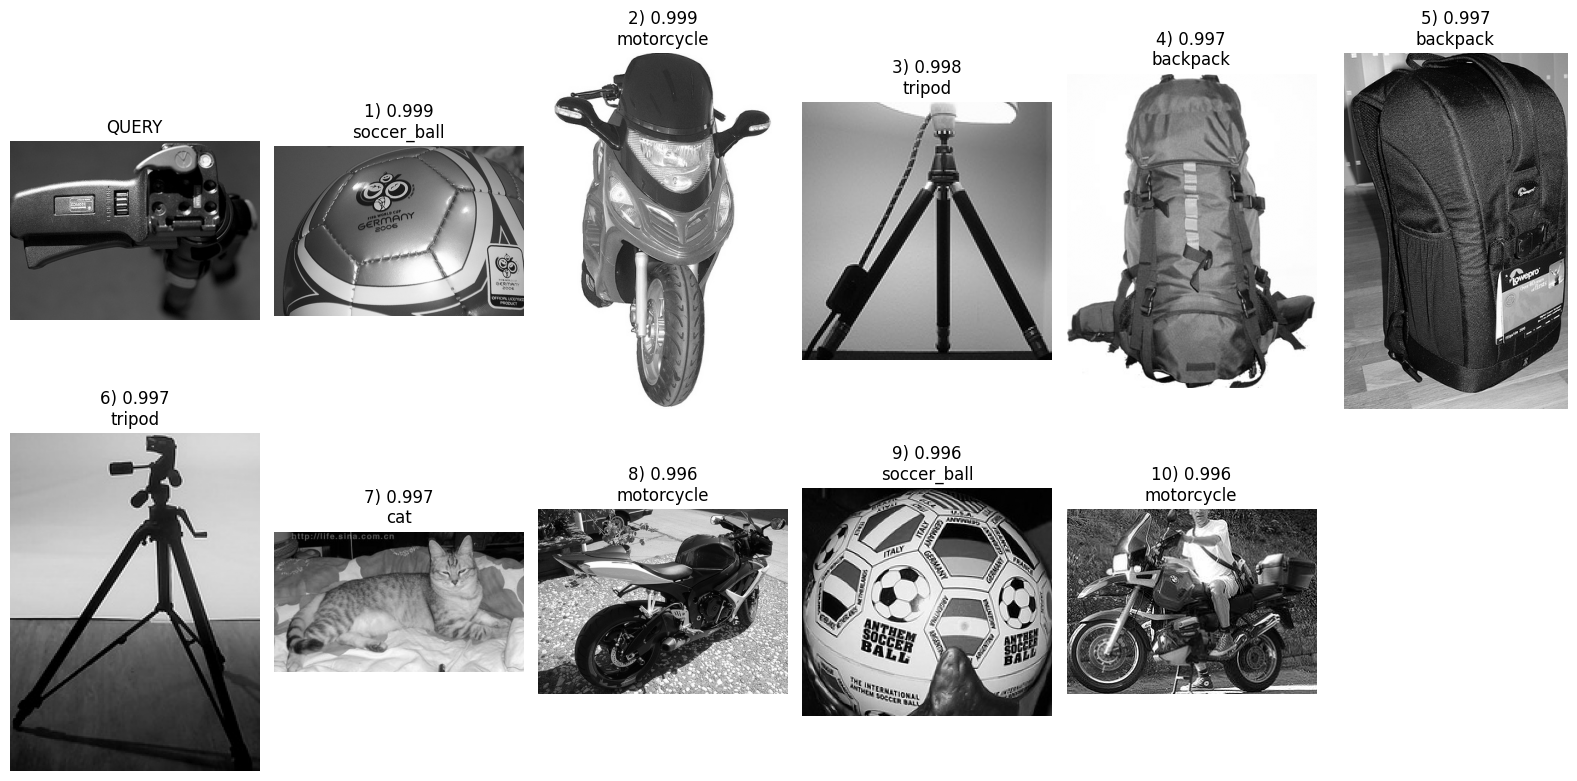

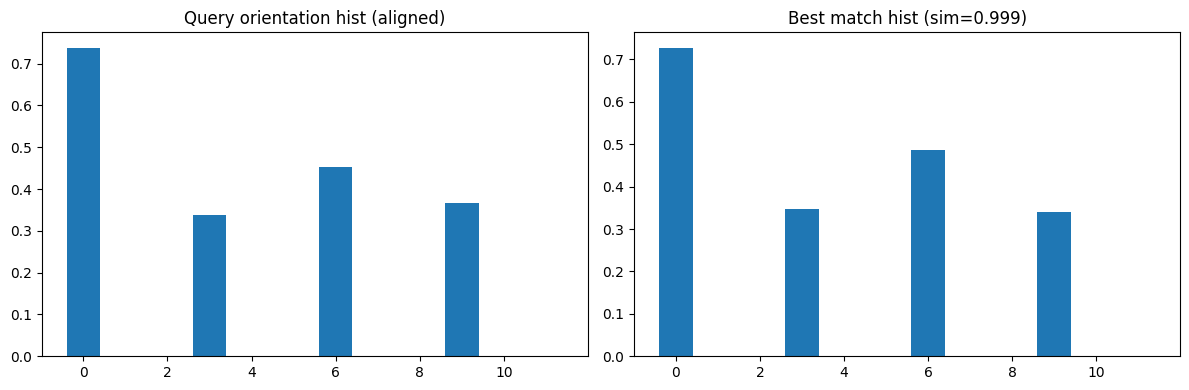

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------------
# CONFIG
# -----------------------------
ROOT = Path("../../")
IMG_DIR = ROOT / "imagenet_yolo15/images/train"
WEIGHTS = Path("../../api/models/yolo/best.pt")

BINS = 36
SAMPLE_N = 200
TOPK = 10
random.seed(788)

# -----------------------------
# Init services
# -----------------------------
yolo = YoloService(weights_path=WEIGHTS, conf=0.25, iou=0.45, imgsz=640)
orient = OrientationHistogramExtractor(bins=BINS, contour_mode="canny")

# -----------------------------
# Helpers
# -----------------------------
def area_xyxy(xyxy):
    x1, y1, x2, y2 = xyxy
    return max(0, x2 - x1) * max(0, y2 - y1)

def yolo_crop_gray(img_path: Path):
    """Detect 1 object (largest bbox), return (crop_gray, det_dict)."""
    dets = yolo.detect(str(img_path))
    if not dets:
        return None, None

    det = max(dets, key=lambda d: area_xyxy(d["bbox_xyxy"]))
    x1, y1, x2, y2 = map(int, det["bbox_xyxy"])

    # load grayscale using the extractor pipeline (float32 ok)
    img_gray = orient._load_image(img_path)

    h, w = img_gray.shape[:2]
    x1 = max(0, min(x1, w - 1)); x2 = max(0, min(x2, w))
    y1 = max(0, min(y1, h - 1)); y2 = max(0, min(y2, h))
    if x2 <= x1 or y2 <= y1:
        return None, None

    crop = img_gray[y1:y2, x1:x2]
    if crop.size == 0:
        return None, None

    return crop, det

def cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    denom = (np.linalg.norm(a) * np.linalg.norm(b))
    if denom <= 1e-12:
        return 0.0
    return float(np.dot(a, b) / denom)

# -----------------------------
# Pick QUERY image
# -----------------------------
imgs = [p for p in IMG_DIR.rglob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}]
assert imgs, "No images found"

query_path = random.choice(imgs)
query_crop, query_det = yolo_crop_gray(query_path)

# if YOLO fails on this image, keep trying a few times
tries = 0
while query_crop is None and tries < 30:
    query_path = random.choice(imgs)
    query_crop, query_det = yolo_crop_gray(query_path)
    tries += 1

assert query_crop is not None, "Could not find a query image with a valid YOLO crop."

query_feat = orient.extract(query_crop)["vector"]
query_label = query_det["class_name"]

print("QUERY:", query_path)
print("QUERY class:", query_label, "conf:", query_det["confidence"], "bbox:", query_det["bbox_xyxy"])

# -----------------------------
# Sample 200 candidates (excluding the query image)
# -----------------------------
candidates = [p for p in imgs if p != query_path]
sample_paths = random.sample(candidates, k=min(SAMPLE_N, len(candidates)))

results = []
valid = 0

for p in sample_paths:
    crop, det = yolo_crop_gray(p)
    if crop is None:
        continue

    feat = orient.extract(crop)["vector"]
    sim = cosine_sim(query_feat, feat)

    results.append((sim, p, crop, det["class_name"], det["confidence"], det["bbox_xyxy"]))
    valid += 1

print(f"Valid candidates used: {valid}/{len(sample_paths)}")

# sort by similarity desc and take topK
results.sort(key=lambda x: x[0], reverse=True)
top = results[:TOPK]

# -----------------------------
# Plot: query + top 10
# -----------------------------
plt.figure(figsize=(16, 8))

# Query (left)
plt.subplot(2, 6, 1)
plt.title("QUERY")
plt.imshow(query_crop, cmap="gray")
plt.axis("off")

# TopK
for i, (sim, p, crop, cls, conf, bbox) in enumerate(top, start=1):
    plt.subplot(2, 6, i + 1)
    plt.title(f"{i}) {sim:.3f}\n{cls}")
    plt.imshow(crop, cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Optional: also plot query histogram and best match histogram
if top:
    best_sim, best_path, best_crop, best_cls, best_conf, best_bbox = top[0]
    q_hist = query_feat
    b_hist = orient.extract(best_crop)["vector"]

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.title("Query orientation hist (aligned)")
    plt.bar(np.arange(len(q_hist)), q_hist)
    plt.subplot(1, 2, 2)
    plt.title(f"Best match hist (sim={best_sim:.3f})")
    plt.bar(np.arange(len(b_hist)), b_hist)
    plt.tight_layout()
    plt.show()


QUERY image: ..\..\imagenet_yolo15\images\train\n02084071_15876.JPEG
QUERY object: dog conf: 0.9483879208564758


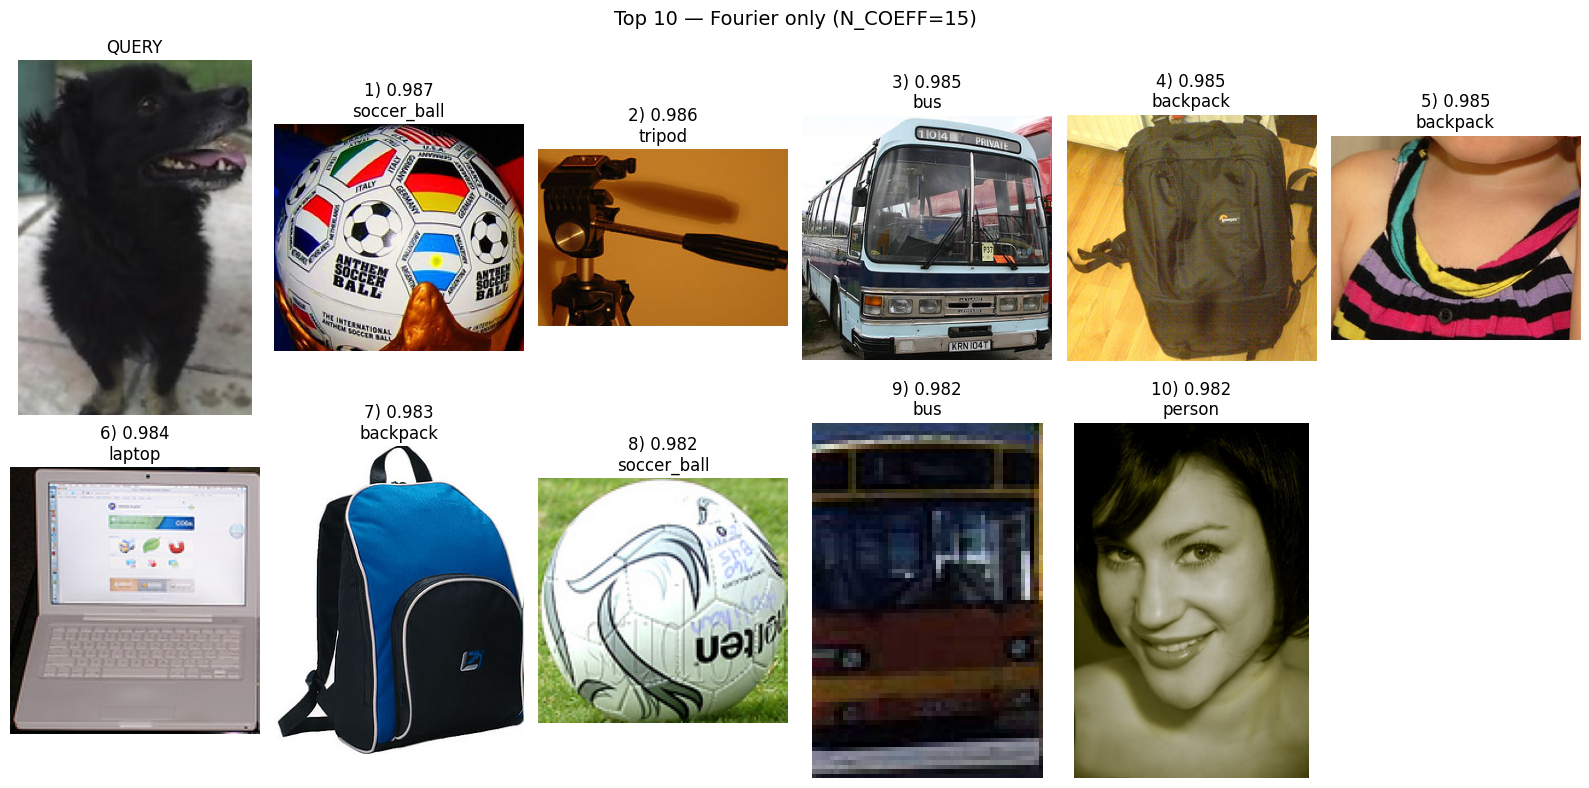

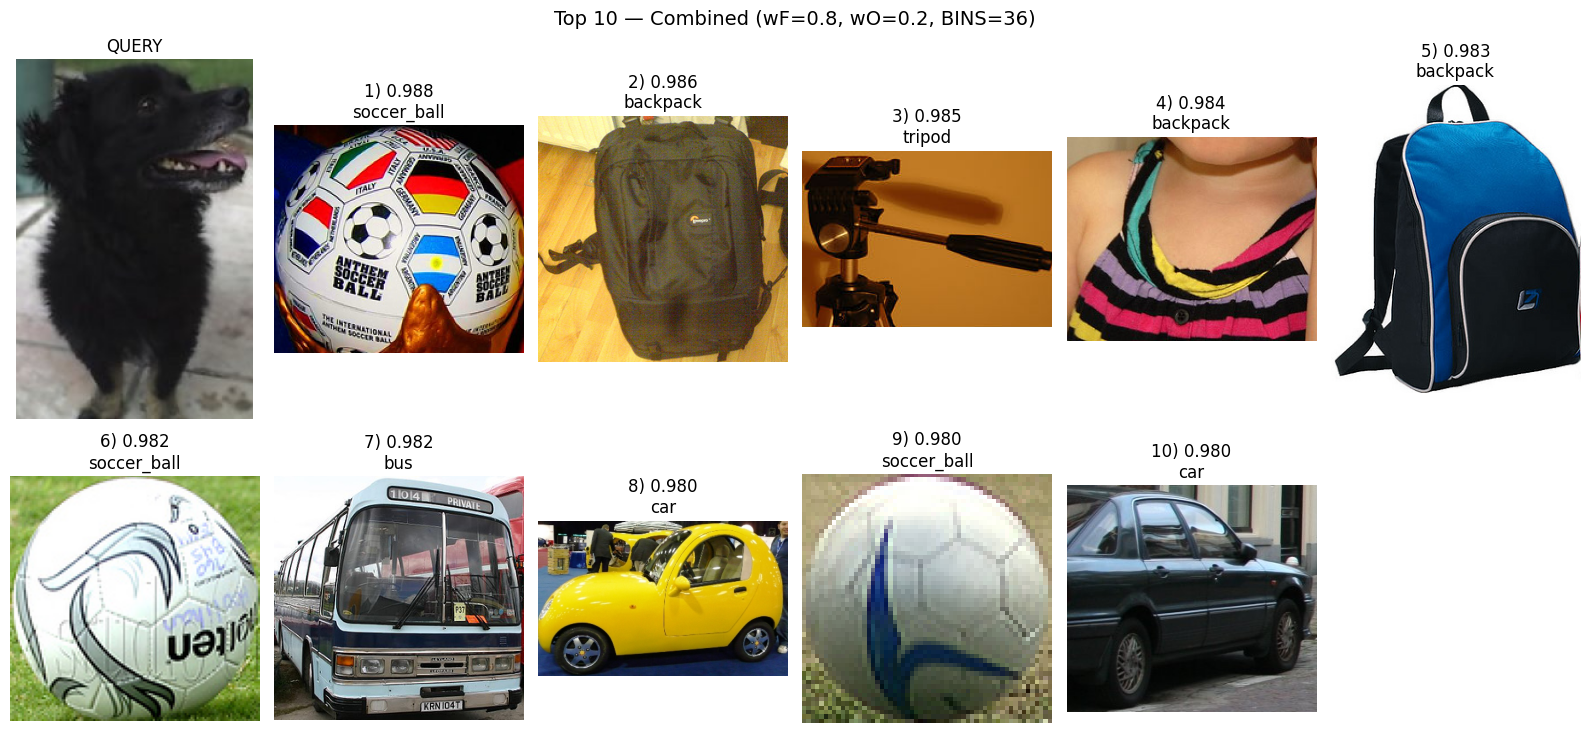

Same-class in Top10:
  Fourier only : 0 / 10
  Combined     : 0 / 10


In [20]:
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import cv2

# ============================================================
# CONFIG (tune these)
# ============================================================
ROOT = Path("../../")
IMG_DIR = ROOT / "imagenet_yolo15/images/train"
WEIGHTS = Path("../../api/models/yolo/best.pt")

SAMPLE_N = 500
TOPK = 10
MAX_OBJS_PER_IMAGE = None  # e.g. 5 to speed up

# Descriptor params
N_COEFF = 15
BINS = 36
wF, wO = 0.8, 0.2

# YOLO params
YOLO_CONF = 0.25
YOLO_IOU = 0.45
YOLO_IMGSZ = 640

random.seed(43)
np.random.seed(43)

# ============================================================
# INIT
# ============================================================
yolo = YoloService(weights_path=WEIGHTS, conf=YOLO_CONF, iou=YOLO_IOU, imgsz=YOLO_IMGSZ)

fourier = FourierDescriptorExtractor(n_coeff=N_COEFF, contour_mode="canny")
orient  = OrientationHistogramExtractor(bins=BINS, contour_mode="canny")

# ============================================================
# Helpers
# ============================================================
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".JPG", ".JPEG", ".PNG", ".BMP"}

def area_xyxy(xyxy):
    x1, y1, x2, y2 = map(int, xyxy)
    return max(0, x2 - x1) * max(0, y2 - y1)

def cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    denom = (np.linalg.norm(a) * np.linalg.norm(b))
    if denom <= 1e-12:
        return 0.0
    return float(np.dot(a, b) / denom)

def combine_vectors(vF, vO, wF, wO):
    v = np.concatenate([wF * vF, wO * vO]).astype(np.float32)
    n = np.linalg.norm(v)
    return v / n if n > 0 else v

# ---- image loading ----
def load_gray(path: Path) -> np.ndarray:
    return fourier._load_image(path)  # float32 gray

def load_rgb(path: Path) -> np.ndarray:
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Could not load image {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def crop_from_bbox(img, bbox_xyxy):
    x1, y1, x2, y2 = map(int, bbox_xyxy)
    h, w = img.shape[:2]
    x1 = max(0, min(x1, w - 1)); x2 = max(0, min(x2, w))
    y1 = max(0, min(y1, h - 1)); y2 = max(0, min(y2, h))
    if x2 <= x1 or y2 <= y1:
        return None
    crop = img[y1:y2, x1:x2]
    return crop if crop.size > 0 else None

def compute_desc(crop_gray):
    vF = fourier.extract(crop_gray)["vector"]
    vO = orient.extract(crop_gray)["vector"]
    vC = combine_vectors(vF, vO, wF, wO)
    return vF, vO, vC

# ============================================================
# Collect images
# ============================================================
all_imgs = [p for p in IMG_DIR.rglob("*") if p.suffix in IMG_EXTS]
assert all_imgs, "No images found"

# ============================================================
# 1) Pick QUERY object
# ============================================================
while True:
    query_path = random.choice(all_imgs)
    dets = yolo.detect(str(query_path))
    if dets:
        break

query_det = max(dets, key=lambda d: area_xyxy(d["bbox_xyxy"]))

img_gray_q = load_gray(query_path)
img_rgb_q  = load_rgb(query_path)

query_crop_gray = crop_from_bbox(img_gray_q, query_det["bbox_xyxy"])
query_crop_rgb  = crop_from_bbox(img_rgb_q,  query_det["bbox_xyxy"])
assert query_crop_gray is not None

query_F, query_O, query_C = compute_desc(query_crop_gray)

query_cls = query_det["class_name"]
query_conf = query_det["confidence"]

print("QUERY image:", query_path)
print("QUERY object:", query_cls, "conf:", query_conf)

# ============================================================
# 2) Candidate images (Option 2)
# ============================================================
candidates = [p for p in all_imgs if p != query_path]
sample_paths = random.sample(candidates, k=min(SAMPLE_N, len(candidates)))

results_F = []
results_C = []

for p in sample_paths:
    dets = yolo.detect(str(p))
    if not dets:
        continue

    if MAX_OBJS_PER_IMAGE:
        dets = sorted(dets, key=lambda d: area_xyxy(d["bbox_xyxy"]), reverse=True)[:MAX_OBJS_PER_IMAGE]

    img_gray = load_gray(p)
    img_rgb  = load_rgb(p)

    bestF = (-1, None)
    bestC = (-1, None)

    for det in dets:
        crop_gray = crop_from_bbox(img_gray, det["bbox_xyxy"])
        crop_rgb  = crop_from_bbox(img_rgb,  det["bbox_xyxy"])
        if crop_gray is None or crop_rgb is None:
            continue

        vF, vO, vC = compute_desc(crop_gray)

        simF = cosine_sim(query_F, vF)
        simC = cosine_sim(query_C, vC)

        payload = {
            "crop_rgb": crop_rgb,
            "class_name": det["class_name"],
            "confidence": det["confidence"],
        }

        if simF > bestF[0]:
            bestF = (simF, payload)
        if simC > bestC[0]:
            bestC = (simC, payload)

    if bestF[1] and bestC[1]:
        results_F.append(bestF)
        results_C.append(bestC)

# ============================================================
# Sort + TopK
# ============================================================
results_F.sort(key=lambda x: x[0], reverse=True)
results_C.sort(key=lambda x: x[0], reverse=True)

topF = results_F[:TOPK]
topC = results_C[:TOPK]

# ============================================================
# Visualization
# ============================================================
def show(title, query_crop_rgb, results):
    plt.figure(figsize=(16, 8))
    plt.suptitle(title, fontsize=14)

    plt.subplot(2, 6, 1)
    plt.title("QUERY")
    plt.imshow(query_crop_rgb)
    plt.axis("off")

    for i, (sim, payload) in enumerate(results, start=1):
        plt.subplot(2, 6, i + 1)
        plt.title(f"{i}) {sim:.3f}\n{payload['class_name']}")
        plt.imshow(payload["crop_rgb"])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show(
    title=f"Top {TOPK} — Fourier only (N_COEFF={N_COEFF})",
    query_crop_rgb=query_crop_rgb,
    results=topF,
)

show(
    title=f"Top {TOPK} — Combined (wF={wF}, wO={wO}, BINS={BINS})",
    query_crop_rgb=query_crop_rgb,
    results=topC,
)

# ============================================================
# Quick proxy metric
# ============================================================
def same_class(top):
    return sum(1 for _, p in top if p["class_name"] == query_cls)

print(f"Same-class in Top{TOPK}:")
print("  Fourier only :", same_class(topF), "/", TOPK)
print("  Combined     :", same_class(topC), "/", TOPK)
